# Projeto e Análise de Algoritmos
## Tema: Recuperação eficiente de contexto em artigos científicos sobre modelos de linguagem, recuperação de informação e RAG

### Discentes:
- CLARIANE MARIA OLIVEIRA LISBOA
- IRIS AZENATE FERREIRA
- JOSÉ NILTON DOS SANTOS OLIVEIRA
- LEONARDO SOUZA SILVA
- THIAGO DE JESUS DOS SANTOS
- VICTÓRIA CARDOSO DOS SANTOS


## 1. Instalação das dependências


In [182]:
!pip install --upgrade requests
%pip install acl-anthology -q
%pip install sentence-transformers -q
%pip install nltk -q

import re
import time
import platform
import sys
import os
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from acl_anthology import Anthology

# Mantém os mesmos resultados nas etapas que usam valores aleatórios
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Definição do corpus

- O corpus é formado por artigos da ACL Anthology, a biblioteca digital oficial da Association for Computational Linguistics, que reúne publicações de conferências na área de Processamento de Linguagem Natural.
- Usamos título + abstract, em vez de baixar e processar PDFs completos.
- A coleta utiliza o pacote Python oficial `acl-anthology`, que baixa os metadados diretamente do repositório oficial da ACL Anthology no GitHub.
- Como a biblioteca não oferece um índice de busca por relevância, aplicamos uma pontuação lexical simples (contagem de ocorrências dos termos da consulta em título+abstract) para selecionar os artigos mais relacionados ao tema, entre as dezenas de milhares disponíveis na Anthology.

In [183]:
QUERY_TERMS = [
    "retrieval augmented generation",
    "information retrieval",
    "large language model",
]


N_ARTIGOS_COLETA = 18000

# Soma das ocorrências de cada termo no texto.
def score_relevancia(texto, termos):
    return sum(texto.count(termo) for termo in termos)


def coletar_corpus_acl(termos, n=100):
    anthology = Anthology.from_repo()

    candidatos = []

    for paper in anthology.papers():
        if paper.abstract is None or paper.title is None:
            continue

        titulo = str(paper.title)
        abstract = str(paper.abstract)
        texto = (titulo + " " + abstract).lower()

        score = score_relevancia(texto, termos)

        if score > 0:
            candidatos.append({
                "id": paper.full_id,
                "title": titulo,
                "abstract": abstract,
                "year": paper.year,
                "doi": paper.doi,
                "url": paper.web_url,
                "_score": score
            })

    # ordena por relevância (score) e, em empate, pelos mais recentes
    candidatos.sort(
        key=lambda x: (x["_score"], x["year"] or 0),
        reverse=True
    )

    top = candidatos[:n]

    df = pd.DataFrame(top).drop(columns=["_score"])
    return df


df = coletar_corpus_acl(
    QUERY_TERMS,
    N_ARTIGOS_COLETA
)

print("Artigos coletados:", len(df))
display(df[["title", "year", "url"]])

Artigos coletados: 18000


,title,year,url
0,LlmFixer: Fix the Helpfulness of Defensive Lar...,2025,https://aclanthology.org/2025.findings-emnlp.989/
1,Measuring Social Norms of Large Language Models,2024,https://aclanthology.org/2024.findings-naacl.43/
2,Flaw or Artifact? Rethinking Prompt Sensitivit...,2025,https://aclanthology.org/2025.emnlp-main.1006/
3,CLaMP 2: Multimodal Music Information Retrieva...,2025,https://aclanthology.org/2025.findings-naacl.27/
4,Evaluating the Long-Term Memory of Large Langu...,2025,https://aclanthology.org/2025.findings-acl.1014/
...,...,...,...
17995,Dictionary and Monolingual Corpus-based Query ...,2010,https://aclanthology.org/L10-1032/
17996,Evaluation of Document Citations in Phase 2 Ga...,2010,https://aclanthology.org/L10-1067/
17997,Indexing Methods for Faster and More Effective...,2010,https://aclanthology.org/L10-1107/
17998,Resource Creation for Training and Testing of ...,2010,https://aclanthology.org/L10-1121/


## 3. Normalização e representação

Decidimos usar uma representação lexical simples:
- tudo em minúsculas;
- sem caracteres especiais;
- tokens separados por espaço, com título e abstract concatenados como texto do documento (aplicamos stemming também, pra reduzir variações de uma mesma palavra).

## 4. Chunking

 - 1 artigo = 1 chunk;
 - Assim, N passa a representar diretamente o número de artigos do corpus, que é também o número de chunks.

In [184]:
def normalizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def tokenizar(texto):
    tokens = normalizar(texto).split()
    return [stemmer.stem(t) for t in tokens]

# Chunking
def preparar_documentos(df):
    documentos = []

    for _, row in df.iterrows():
        texto = (
            str(row["title"]) + " " +
            str(row["abstract"])
        )

        documentos.append({
            "id": row["id"],
            "title": row["title"],
            "text": normalizar(texto),
            "tokens": tokenizar(normalizar(texto)),
            "url": row["url"],
            "year": row["year"]
        })
    return documentos


documentos = preparar_documentos(df)


## 5. Consultas

- Foram utilizadas dez perguntas de recuperação.
- A ideia é verificar se os algoritmos conseguem recuperar artigos relacionados a diferentes aspectos do tema.

In [185]:
QUERIES = {
    "Q1": "What information retrieval methods are used in RAG systems?",
    "Q2": "Which studies compare sparse retrieval and dense retrieval?",
    "Q3": "What semantic search techniques are used to retrieve context for language models?",
    "Q4": "What reranking methods are used in retrieval systems for LLMs?",
    "Q5": "What metrics are used to evaluate Retrieval-Augmented Generation systems?",
    "Q6": "Which papers use embeddings for document retrieval?",
    "Q7": "What techniques are used to select the most relevant documents or excerpts for a language model?",
    "Q8": "Which methods were compared for context retrieval?",
    "Q9": "What limitations of RAG systems are reported in the articles?",
    "Q10": "What chunking strategies are used in document retrieval?"
}

## 6. Função de relevância

 - Usamos pontuação lexical: soma da frequência de cada termo da consulta no documento.
 - Quanto mais vezes os termos da consulta aparecem no documento, maior o score. Essa é a função usada de fato pelos três algoritmos de busca (linear, indexada e com Merge Sort), o que facilita a análise pelo Modelo RAM e a contagem de comparações, já que cada ocorrência checada é uma operação elementar simples de contar.


In [186]:
STOPWORDS = {
    "the", "and", "or", "of", "to", "a", "in",
    "for", "on", "with", "as", "is", "are",
    "was", "were", "what", "which", "how"
}

def query_tokens(query):
    return [
        t for t in tokenizar(query)
        if t not in STOPWORDS
    ]

def score_documento(documento, consulta):
    tokens_documento = documento["tokens"]
    termos_consulta = query_tokens(consulta)
    return sum(tokens_documento.count(t) for t in termos_consulta)

def construir_gabarito_lexical(documentos, queries, threshold=2):
    gabarito = {}
    for qid, consulta in queries.items():
        relevantes = {
            doc["id"] for doc in documentos
            if score_documento(doc, consulta) >= threshold
        }
        gabarito[qid] = relevantes
    return gabarito

## 6.1 Gabarito de relevância via embeddings

- A pontuação lexical acima decide o que os algoritmos retornam, mas não serve pra avaliar se esse retorno é bom, porque estaríamos comparando o método com ele mesmo. Por isso construímos um gabarito de relevância à parte, usando embeddings semânticos (`all-MiniLM-L6-v2`) e similaridade de cosseno entre a consulta e cada documento.
- Esse gabarito não participa da busca nem da ordenação em nenhum momento, ele só define, pra cada query, quais artigos consideramos relevantes na hora de calcular o Precision@5 das três configurações (busca linear, índice invertido e Merge Sort).

In [187]:
modelo_embeddings = SentenceTransformer("all-MiniLM-L6-v2")

def construir_gabarito_semantico(documentos, queries, top_n=15):
    textos_doc = [doc["text"] for doc in documentos]
    emb_docs = modelo_embeddings.encode(textos_doc, show_progress_bar=True)

    gabarito = {}
    for qid, consulta in queries.items():
        emb_query = modelo_embeddings.encode([consulta])
        sims = cosine_similarity(emb_query, emb_docs)[0]

        top_idx = sims.argsort()[::-1][:top_n]
        ids_relevantes = {documentos[i]["id"] for i in top_idx}

        gabarito[qid] = ids_relevantes

    return gabarito

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 7. Configuração 1 — Busca Linear

- A busca linear percorre todos os documentos e calcula o score de cada um.

In [188]:
def busca_linear(documentos, consulta, k=5):
    resultados = []
    comparacoes = 0

    for doc in documentos:
        score = score_documento(doc, consulta)
        comparacoes += 1

        resultados.append((score, doc))

    resultados.sort(
        key=lambda x: x[0],
        reverse=True
    )

    return resultados[:k], comparacoes

## 8. Configuração 2 — Índice Invertido

- O índice associa cada termo aos documentos em que ele aparece:
- A consulta recupera apenas os documentos candidatos.

In [189]:
def construir_indice_invertido(documentos):
    indice = {}

    for i, doc in enumerate(documentos):
        palavras = set(tokenizar(doc["text"]))

        for palavra in palavras:
            if palavra not in indice:
                indice[palavra] = []

            indice[palavra].append(i)

    return indice


def busca_indexada(documentos, indice, consulta, k=5):
    candidatos = set()

    for palavra in query_tokens(consulta):
        if palavra in indice:
            candidatos.update(indice[palavra])

    resultados = []
    comparacoes = 0

    for i in candidatos:
        doc = documentos[i]
        score = score_documento(doc, consulta)
        comparacoes += 1

        resultados.append((score, doc))

    resultados.sort(
        key=lambda x: x[0],
        reverse=True
    )

    return resultados[:k], comparacoes

## 9. Configuração 3 — Merge Sort

- O Merge Sort é um algoritmo de divisão e conquista.

In [190]:
def merge_sort(lista):
    if len(lista) <= 1:
        return lista

    meio = len(lista) // 2

    esquerda = merge_sort(lista[:meio])
    direita = merge_sort(lista[meio:])

    return merge(esquerda, direita)


def merge(esquerda, direita):
    resultado = []
    i = 0
    j = 0

    while i < len(esquerda) and j < len(direita):

        if esquerda[i][0] >= direita[j][0]:
            resultado.append(esquerda[i])
            i += 1
        else:
            resultado.append(direita[j])
            j += 1

    resultado.extend(esquerda[i:])
    resultado.extend(direita[j:])

    return resultado


def busca_merge_sort(documentos, consulta, k=5):
    resultados = []
    comparacoes = 0

    for doc in documentos:
        score = score_documento(doc, consulta)
        comparacoes += 1

        resultados.append((score, doc))

    resultados = merge_sort(resultados)

    return resultados[:k], comparacoes

## 10. Casos de borda

- Foram testadas as três configurações em situações de borda, como corpus vazio, consulta vazia, consulta formada somente por stopwords, termos ausentes do corpus, valores inválidos de \(k\) e empates de pontuação. Os testes verificaram tanto os comportamentos comuns quanto as diferenças esperadas entre as configurações.

In [206]:
def testar_casos_de_borda():
    documentos_teste = [
        {
            "id": "D1",
            "text": "retrieval augmented generation",
            "tokens": tokenizar("retrieval augmented generation")
        },
        {
            "id": "D2",
            "text": "retrieval information retrieval",
            "tokens": tokenizar("retrieval information retrieval")
        },
        {
            "id": "D3",
            "text": "large language model",
            "tokens": tokenizar("large language model")
        }
    ]

    indice_teste = construir_indice_invertido(documentos_teste)

    # Consulta vazia:
    linear, _ = busca_linear(
        documentos_teste, "", 5
    )

    indexada, _ = busca_indexada(
        documentos_teste,
        indice_teste,
        "",
        5
    )

    merge_resultado, _ = busca_merge_sort(
        documentos_teste, "", 5
    )

    assert len(linear) == 3
    assert all(score == 0 for score, _ in linear)

    assert indexada == []

    assert len(merge_resultado) == 3
    assert all(
        score == 0
        for score, _ in merge_resultado
    )

    # Consulta formada somente por stopwords:
    # após o tratamento, a consulta não possui termos válidos.
    linear, _ = busca_linear(
        documentos_teste,
        "the and of",
        5
    )

    indexada, _ = busca_indexada(
        documentos_teste,
        indice_teste,
        "the and of",
        5
    )

    merge_resultado, _ = busca_merge_sort(
        documentos_teste,
        "the and of",
        5
    )

    assert len(linear) == 3
    assert all(score == 0 for score, _ in linear)

    assert indexada == []

    assert len(merge_resultado) == 3
    assert all(
        score == 0
        for score, _ in merge_resultado
    )

    # Consulta com termos inexistentes no corpus:
    linear, _ = busca_linear(
        documentos_teste,
        "computer vision",
        5
    )

    indexada, _ = busca_indexada(
        documentos_teste,
        indice_teste,
        "computer vision",
        5
    )

    merge_resultado, _ = busca_merge_sort(
        documentos_teste,
        "computer vision",
        5
    )

    assert len(linear) == 3
    assert all(score == 0 for score, _ in linear)

    assert indexada == []

    assert len(merge_resultado) == 3
    assert all(
        score == 0
        for score, _ in merge_resultado
    )

    # Corpus vazio
    assert busca_linear(
        [], "retrieval", 5
    )[0] == []

    assert busca_merge_sort(
        [], "retrieval", 5
    )[0] == []

    indice_vazio = construir_indice_invertido([])

    assert busca_indexada(
        [],
        indice_vazio,
        "retrieval",
        5
    )[0] == []

    # k igual a zero
    assert busca_linear(
        documentos_teste,
        "retrieval",
        0
    )[0] == []

    assert busca_indexada(
        documentos_teste,
        indice_teste,
        "retrieval",
        0
    )[0] == []

    assert busca_merge_sort(
        documentos_teste,
        "retrieval",
        0
    )[0] == []

    # Empate de pontuação
    documentos_empate = [
        {
            "id": "E1",
            "text": "retrieval",
            "tokens": tokenizar("retrieval")
        },
        {
            "id": "E2",
            "text": "retrieval",
            "tokens": tokenizar("retrieval")
        }
    ]

    indice_empate = construir_indice_invertido(
        documentos_empate
    )

    linear_empate, _ = busca_linear(
        documentos_empate,
        "retrieval",
        5
    )

    indexada_empate, _ = busca_indexada(
        documentos_empate,
        indice_empate,
        "retrieval",
        5
    )

    merge_empate, _ = busca_merge_sort(
        documentos_empate,
        "retrieval",
        5
    )

    for resultado in (
        linear_empate,
        indexada_empate,
        merge_empate
    ):
        ids = {
            doc["id"]
            for _, doc in resultado
        }

        assert ids == {"E1", "E2"}

        assert all(
            score == 1
            for score, _ in resultado
        )

    # Consulta normal:
    # são comparados somente os documentos com score positivo,
    # pois Linear e Merge Sort também retornam documentos com score zero.
    linear, _ = busca_linear(
        documentos_teste,
        "retrieval",
        5
    )

    indexada, _ = busca_indexada(
        documentos_teste,
        indice_teste,
        "retrieval",
        5
    )

    merge_resultado, _ = busca_merge_sort(
        documentos_teste,
        "retrieval",
        5
    )

    ids_linear_positivos = {
        doc["id"]
        for score, doc in linear
        if score > 0
    }

    ids_indexados_positivos = {
        doc["id"]
        for score, doc in indexada
        if score > 0
    }

    ids_merge_positivos = {
        doc["id"]
        for score, doc in merge_resultado
        if score > 0
    }

    assert (
        ids_linear_positivos
        == ids_indexados_positivos
        == ids_merge_positivos
    )

    assert ids_linear_positivos == {"D1", "D2"}

    print("Todos os casos de borda passaram.")


testar_casos_de_borda()

Todos os casos de borda passaram.


## 11. Testes de corretude — Merge Sort

- Antes de utilizar o algoritmo no experimento, fazemos testes automatizados comparando o resultado do nosso Merge Sort com a ordenação de referência do Python.

In [192]:
def testar_merge_sort():
    casos = [
        [],
        [1],
        [2, 1],
        [3, 1, 2],
        [5, 4, 3, 2, 1],
        [1, 2, 3, 4, 5],
        [4, 2, 4, 1, 3]
    ]

    for caso in casos:
        entrada = [(x, i, None) for i, x in enumerate(caso)]

        resultado = merge_sort(entrada)

        esperado = sorted(
            entrada,
            key=lambda x: (-x[0], x[1])
        )

        assert resultado == esperado

    print("Todos os testes passaram.")


testar_merge_sort()

Todos os testes passaram.


## 12. Precision@5

- Como medida simples de qualidade, usamos Precision@5.
- A relevância aqui vem do gabarito semântico da seção 6.1, construído com embeddings e similaridade de cosseno, e não de um critério lexical. Escolhemos assim pra evitar o problema de comparar a busca lexical com um critério de relevância também lexical, o que inflaria artificialmente a precisão das configurações que já pontuam por frequência de termos.


In [193]:
def relevante(documento, qid, gabarito):
    return documento["id"] in gabarito[qid]


def precision_at_k(resultados, qid, gabarito, k=5):
    if len(resultados) == 0:
        return 0.0

    avaliados = resultados[:k]

    relevantes = sum(
        relevante(doc, qid, gabarito)
        for _, doc in avaliados
    )

    return relevantes / k

## 13. Função de experimento

Cada execução registra:

- tamanho do corpus;
- configuração;
- consulta;
- repetição;
- tempo de consulta;
- número de comparações;
- Precision@5;
- quantidade de resultados.

In [194]:
def executar_configuracao(
    configuracao, documentos, qid, consulta, gabarito,
    k=5, indice=None, tempo_preprocessamento=0.0
):
    inicio = time.perf_counter()

    if configuracao == "Busca Linear":
        resultados, comparacoes = busca_linear(documentos, consulta, k)
    elif configuracao == "Índice Invertido":
        resultados, comparacoes = busca_indexada(documentos, indice, consulta, k)
    elif configuracao == "Merge Sort":
        resultados, comparacoes = busca_merge_sort(documentos, consulta, k)
    else:
        raise ValueError("Configuração inválida.")

    tempo_consulta = time.perf_counter() - inicio
    precisao = precision_at_k(resultados, qid, gabarito, k)

    resultado_vazio = len(resultados) == 0
    sem_item_relevante = (not resultado_vazio) and (precisao == 0.0)

    return {
        "tempo_preprocessamento": tempo_preprocessamento,
        "tempo_consulta": tempo_consulta,
        "tempo_total": tempo_preprocessamento + tempo_consulta,
        "comparacoes": comparacoes,
        "precision_at_5": precisao,
        "n_resultados": len(resultados),
        "resultado_vazio": resultado_vazio,
        "sem_item_relevante": sem_item_relevante,
    }

## 14. Executando o experimento

Serão utilizados:

- 500 artigos;
- 1000 artigos;
- 3 configurações (Busca Linear, Índice Invertido, Merge Sort);
- 10 consultas (Q1 a Q10);
- 30 repetições por cenário.

No total: 2 × 3 × 10 × 30 = 1800 execuções mensuráveis.

In [195]:
import time
import tracemalloc
import pandas as pd


CONFIGURACOES = [
    "Busca Linear",
    "Índice Invertido",
    "Merge Sort"
]

TAMANHOS = [500, 1000]
REPETICOES = 30
K = 5

In [196]:
def medir_memoria(funcao, *args, **kwargs):
    tracemalloc.start()

    resultado = funcao(*args, **kwargs)

    memoria_atual, pico_memoria = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    pico_memoria_mb = pico_memoria / (1024 ** 2)

    return resultado, pico_memoria_mb

def medir_tempo_preprocessamento(df_bruto, tamanho, repeticoes=10):
    tempos = []

    for _ in range(repeticoes):
        inicio = time.perf_counter()
        _ = preparar_documentos(df_bruto.iloc[:tamanho])
        tempos.append(time.perf_counter() - inicio)

    return sum(tempos) / len(tempos)

In [197]:
_ = preparar_documentos(df.iloc[:10])

In [198]:
resultados_experimento = []
tempos_construcao_indice = []

for tamanho in TAMANHOS:
    corpus_teste = documentos[:tamanho]

    tempo_preproc = medir_tempo_preprocessamento(df, tamanho)

    gabarito_teste = construir_gabarito_semantico(
        corpus_teste,
        QUERIES,
        top_n=15
    )

    inicio_indice = time.perf_counter()
    indice_teste, pico_memoria_indice = medir_memoria(
        construir_indice_invertido,
        corpus_teste
    )
    tempo_construcao_indice = (
        time.perf_counter() - inicio_indice
    )

    tempos_construcao_indice.append({
        "corpus": tamanho,
        "tempo_construcao_indice": tempo_construcao_indice,
        "pico_memoria_indice_mb": pico_memoria_indice
    })

    for qid, consulta in QUERIES.items():
        for configuracao in CONFIGURACOES:
            for repeticao in range(1, REPETICOES + 1):
                resultado, pico_memoria = medir_memoria(
                    executar_configuracao,
                    configuracao,
                    corpus_teste,
                    qid,
                    consulta,
                    gabarito_teste,
                    K,
                    indice=(
                        indice_teste
                        if configuracao == "Índice Invertido"
                        else None
                    ),
                    tempo_preprocessamento=tempo_preproc
                )
                resultados_experimento.append({
                    "corpus": tamanho,
                    "query_id": qid,
                    "query": consulta,
                    "configuracao": configuracao,
                    "repeticao": repeticao,
                    **resultado,
                    "pico_memoria_mb": pico_memoria
                })


resultados = pd.DataFrame(resultados_experimento)

tempos_indice = pd.DataFrame(
    tempos_construcao_indice
)

display(resultados)
display(tempos_indice)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

,corpus,query_id,query,configuracao,repeticao,tempo_preprocessamento,tempo_consulta,tempo_total,comparacoes,precision_at_5,n_resultados,resultado_vazio,sem_item_relevante,pico_memoria_mb
0,500,Q1,What information retrieval methods are used in...,Busca Linear,1,1.558208,0.527709,2.085917,500,0.6,5,False,False,0.011314
1,500,Q1,What information retrieval methods are used in...,Busca Linear,2,1.558208,0.503604,2.061813,500,0.6,5,False,False,0.011314
2,500,Q1,What information retrieval methods are used in...,Busca Linear,3,1.558208,0.518459,2.076667,500,0.6,5,False,False,0.011314
3,500,Q1,What information retrieval methods are used in...,Busca Linear,4,1.558208,0.503147,2.061355,500,0.6,5,False,False,0.011314
4,500,Q1,What information retrieval methods are used in...,Busca Linear,5,1.558208,0.519519,2.077727,500,0.6,5,False,False,0.011314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1795,1000,Q10,What chunking strategies are used in document ...,Merge Sort,26,3.184639,0.952789,4.137428,1000,0.2,5,False,False,0.025398
1796,1000,Q10,What chunking strategies are used in document ...,Merge Sort,27,3.184639,0.941472,4.126110,1000,0.2,5,False,False,0.025398
1797,1000,Q10,What chunking strategies are used in document ...,Merge Sort,28,3.184639,0.948168,4.132807,1000,0.2,5,False,False,0.025398
1798,1000,Q10,What chunking strategies are used in document ...,Merge Sort,29,3.184639,0.969491,4.154129,1000,0.2,5,False,False,0.025826


,corpus,tempo_construcao_indice,pico_memoria_indice_mb
0,500,18.453681,1.091387
1,1000,22.628752,1.892778


## 15. Tabela de resultados
- A tabela abaixo resume os resultados por corpus e configuração, juntando tempo, comparações, qualidade da recuperação, memória e as taxas de falha discutidas na seção anterior.



In [199]:
resumo = (
    resultados
    .groupby(["corpus", "configuracao"])
    .agg(
        tempo_preprocessamento_medio=(
            "tempo_preprocessamento", "mean"
        ),
        tempo_consulta_medio=(
            "tempo_consulta", "mean"
        ),
        tempo_total_medio=(
            "tempo_total", "mean"
        ),
        comparacoes_medias=(
            "comparacoes", "mean"
        ),
        precision_at_5_media=(
            "precision_at_5", "mean"
        ),
        taxa_resultado_vazio=(
            "resultado_vazio", "mean"
        ),
        taxa_sem_relevante=(
            "sem_item_relevante", "mean"
        ),
        memoria_media_mb=(
            "pico_memoria_mb", "mean"
        ),
        memoria_maxima_mb=(
            "pico_memoria_mb", "max"
        )
    )
    .reset_index()
)

display(
    resumo.style.format({
        "tempo_preprocessamento_medio": "{:.6f}",
        "tempo_consulta_medio": "{:.6f}",
        "tempo_total_medio": "{:.6f}",
        "comparacoes_medias": "{:.2f}",
        "precision_at_5_media": "{:.6f}",
        "taxa_resultado_vazio": "{:.2%}",
        "taxa_sem_relevante": "{:.2%}",
        "memoria_media_mb": "{:.4f}",
        "memoria_maxima_mb": "{:.4f}"
    })
)

,corpus,configuracao,tempo_preprocessamento_medio,tempo_consulta_medio,tempo_total_medio,comparacoes_medias,precision_at_5_media,taxa_resultado_vazio,taxa_sem_relevante,memoria_media_mb,memoria_maxima_mb
0,500,Busca Linear,1.558208,0.627106,2.185314,500.00,0.460000,0.00%,10.00%,0.0110,0.0123
1,500,Merge Sort,1.558208,0.627115,2.185323,500.00,0.460000,0.00%,10.00%,0.0126,0.0135
2,500,Índice Invertido,1.558208,0.512741,2.070949,403.50,0.460000,0.00%,10.00%,0.0386,0.0438
3,1000,Busca Linear,3.184639,1.272054,4.456692,1000.00,0.400000,0.00%,10.00%,0.0221,0.0243
4,1000,Merge Sort,3.184639,1.268274,4.452912,1000.00,0.400000,0.00%,10.00%,0.0257,0.0268
5,1000,Índice Invertido,3.184639,1.020687,4.205325,779.40,0.400000,0.00%,10.00%,0.0486,0.0557


In [200]:
tabela_artigo = resumo.rename(columns={
    "corpus": "Corpus",
    "configuracao": "Método",
    "tempo_preprocessamento_medio": "Tempo pré-processamento (s)",
    "tempo_consulta_medio": "Tempo consulta (s)",
    "tempo_total_medio": "Tempo total (s)",
    "comparacoes_medias": "Comparações",
    "precision_at_5_media": "Precision@5 média",
    "taxa_resultado_vazio": "Taxa de resultado vazio",
    "taxa_sem_relevante": "Taxa sem item relevante",
    "memoria_media_mb": "Memória média (MB)",
    "memoria_maxima_mb": "Pico memória (MB)"
})

display(
    tabela_artigo.style.format({
        "Tempo pré-processamento (s)": "{:.4f}",
        "Tempo consulta (s)": "{:.4f}",
        "Tempo total (s)": "{:.4f}",
        "Comparações": "{:.1f}",
        "Precision@5": "{:.2f}",
        "Taxa resultado vazio": "{:.2%}",
        "Taxa sem relevante": "{:.2%}",
        "Memória média (MB)": "{:.4f}",
        "Pico memória (MB)": "{:.4f}"
    }).hide(axis="index")
)

Corpus,Método,Tempo pré-processamento (s),Tempo consulta (s),Tempo total (s),Comparações,Precision@5 média,Taxa de resultado vazio,Taxa sem item relevante,Memória média (MB),Pico memória (MB)
500,Busca Linear,1.5582,0.6271,2.1853,500.0,0.460000,0.000000,0.100000,0.0110,0.0123
500,Merge Sort,1.5582,0.6271,2.1853,500.0,0.460000,0.000000,0.100000,0.0126,0.0135
500,Índice Invertido,1.5582,0.5127,2.0709,403.5,0.460000,0.000000,0.100000,0.0386,0.0438
1000,Busca Linear,3.1846,1.2721,4.4567,1000.0,0.400000,0.000000,0.100000,0.0221,0.0243
1000,Merge Sort,3.1846,1.2683,4.4529,1000.0,0.400000,0.000000,0.100000,0.0257,0.0268
1000,Índice Invertido,3.1846,1.0207,4.2053,779.4,0.400000,0.000000,0.100000,0.0486,0.0557


### 15.1 Custo amortizado da construção do índice

O índice tem um custo fixo de construção, pago uma vez e reaproveitado nas 300 consultas da configuração indexada. Por isso olhamos o custo dividido pelo número de consultas: se o corpus for pouco consultado, construir o índice pode não compensar, reaproveitado muitas vezes, como aqui, o custo inicial se dilui e a busca indexada tende a compensar.

In [201]:
n_execucoes_indice_por_corpus = len(QUERIES) * REPETICOES

tempos_indice["tempo_construcao_amortizado_por_consulta"] = (
    tempos_indice["tempo_construcao_indice"] / n_execucoes_indice_por_corpus
)

display(tempos_indice)

,corpus,tempo_construcao_indice,pico_memoria_indice_mb,tempo_construcao_amortizado_por_consulta
0,500,18.453681,1.091387,0.061512
1,1000,22.628752,1.892778,0.075429


## 15. Gráfico — Tempo de consulta

A principal hipótese experimental é que o índice invertido pode reduzir o trabalho necessário durante a consulta, principalmente quando o número de documentos aumenta.

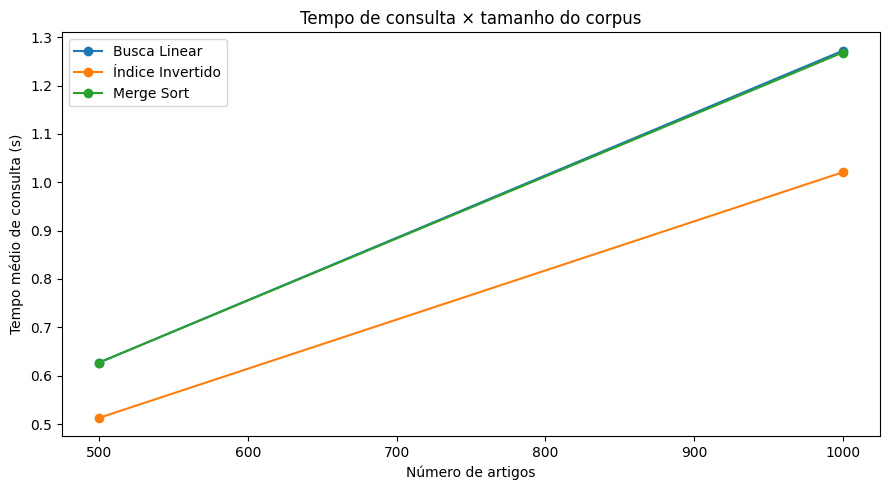

In [202]:
plt.figure(figsize=(9, 5))

for configuracao in CONFIGURACOES:
    dados = (
        resultados[
            resultados["configuracao"] == configuracao
        ]
        .groupby("corpus")["tempo_consulta"]
        .mean()
    )

    plt.plot(
        dados.index,
        dados.values,
        marker="o",
        label=configuracao
    )

plt.xlabel("Número de artigos")
plt.ylabel("Tempo médio de consulta (s)")
plt.title("Tempo de consulta × tamanho do corpus")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Gráfico — Número de comparações

Esse gráfico permite observar a diferença entre percorrer o corpus inteiro e utilizar uma estrutura indexada.

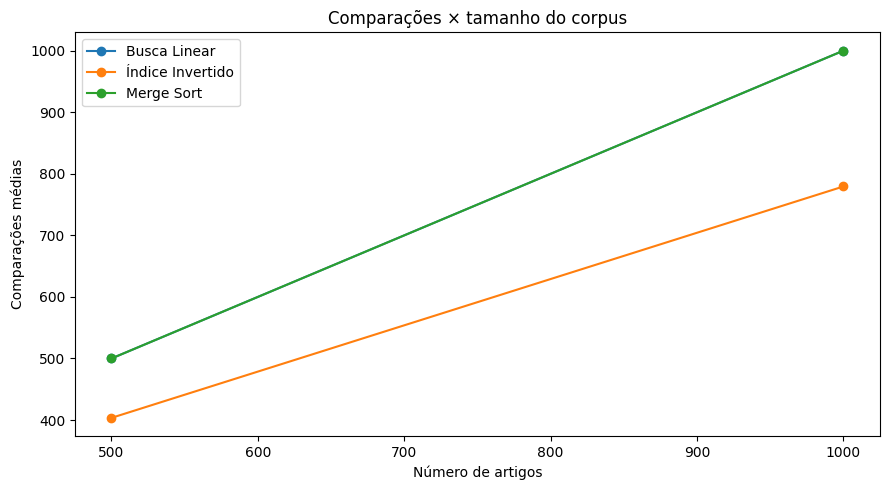

In [203]:
plt.figure(figsize=(9, 5))

for configuracao in CONFIGURACOES:
    dados = (
        resultados[
            resultados["configuracao"] == configuracao
        ]
        .groupby("corpus")["comparacoes"]
        .mean()
    )

    plt.plot(
        dados.index,
        dados.values,
        marker="o",
        label=configuracao
    )

plt.xlabel("Número de artigos")
plt.ylabel("Comparações médias")
plt.title("Comparações × tamanho do corpus")
plt.legend()
plt.tight_layout()
plt.show()

## 17. Gráfico — Precision@5

A eficiência não deve ser analisada isoladamente. Também verificamos se as configurações retornam resultados de qualidade semelhante.

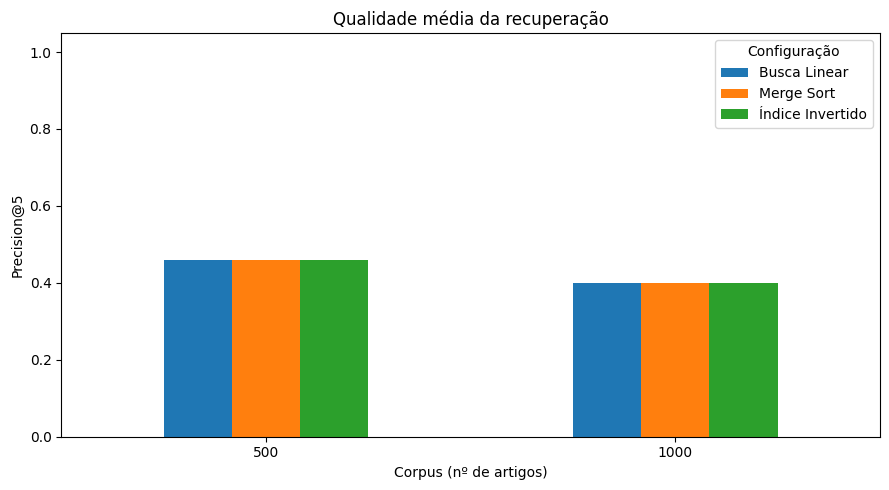

In [204]:
plt.figure(figsize=(9, 5))

dados = (
    resultados
    .groupby(["corpus", "configuracao"])["precision_at_5"]
    .mean()
    .unstack("configuracao")
)

dados.plot(kind="bar", ax=plt.gca())

plt.ylabel("Precision@5")
plt.xlabel("Corpus (nº de artigos)")
plt.title("Qualidade média da recuperação")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Configuração")
plt.tight_layout()
plt.show()

## 18. Gráfico — Uso de memória
Além de tempo e comparações, o modelo RAM também prevê custo de espaço. Aqui olhamos o pico de memória de cada configuração conforme o corpus cresce, pra ver se alguma delas escala pior que as outras nesse quesito.

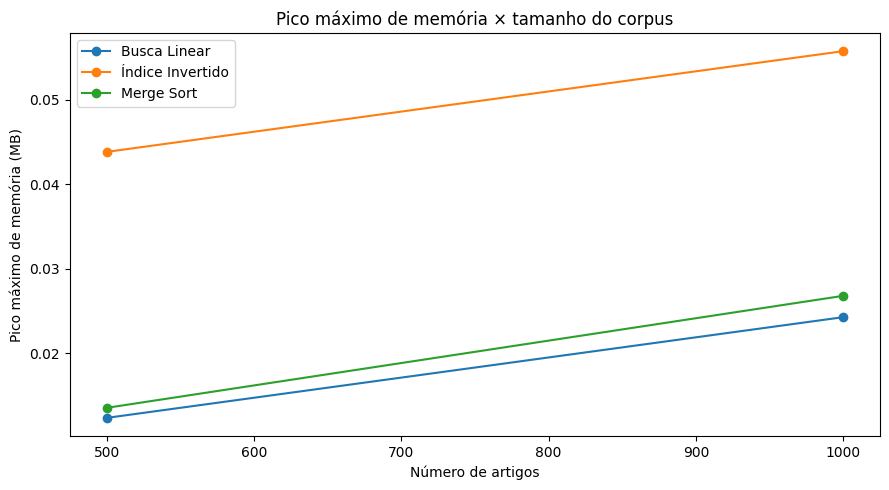

In [205]:
plt.figure(figsize=(9, 5))

for configuracao in CONFIGURACOES:

    dados = (
        resultados[
            resultados["configuracao"] == configuracao
        ]
        .groupby("corpus")["pico_memoria_mb"]
        .max()
    )

    plt.plot(
        dados.index,
        dados.values,
        marker="o",
        label=configuracao
    )

plt.xlabel("Número de artigos")
plt.ylabel("Pico máximo de memória (MB)")
plt.title("Pico máximo de memória × tamanho do corpus")
plt.legend()
plt.tight_layout()
plt.show()